Text length: 200000 characters

--- Training SimpleRNN ---
SimpleRNN | Time: 33.9s | Final Loss: 1.8304

--- Training LSTM ---
LSTM | Time: 78.1s | Final Loss: 1.9044

--- Training GRU ---
GRU | Time: 72.5s | Final Loss: 1.7397


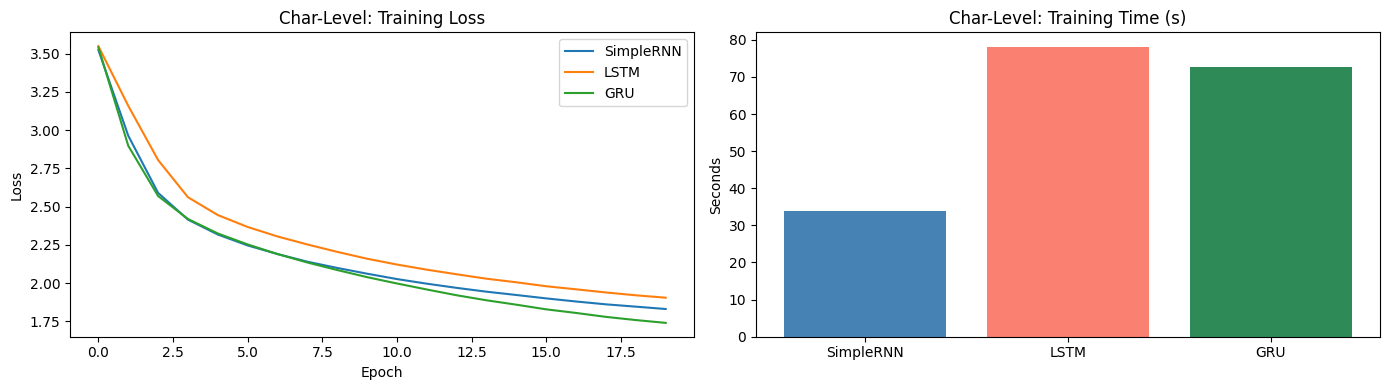


=== SimpleRNN ===
ROMEO: I me thary ghadeno, wigre ghay itritifin wonamasthars ves t COLARFine thad therirengenghithe thelllere ANEd wanden: is w, thagond bamy akenondackerin andorathat trerajouched ghave t llly thed nonithino h in ith cit wivindrer d s!
NCO, grd pllllaly wathik m pren''s.
MENo wanghithach hanen ghis A rAbi

=== LSTM ===
ROMEO: I'RI fowhabl, folrchiricwes y:
Add.
Bze y'ghy t?
Thius.

Beret antene t Cousth laneaxnom.
Fl w.

ThithiberminxiENthibupterece gane MNGOMath relam the, i, at torer cat mous! oury t thithafine, thechatorouassthe at my AHeresoumy fwes h'setprerth,
Th ande thegonde I-I ho mery wiase, w t ovenfoulol:
Car

=== GRU ===
ROMEO: thasthe may
Wen:
oulithour as he oreranoury.
Cilid codethit SIUSThazPUS:
Asthend MI w t fichie h h,
Kene--Fral,
I he!
IBus wallary allauren ch w
Bus ire t o a thin:
Thefe one heibrirainGICI ve tlle hicomenolloushowalit thagouchizWer sth th thexache ghisth nchakevis n s:
Wenoneres:
BCie y: then w
INE

--- Training LSTM-2Layer ---


In [2]:
import numpy as np
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load Shakespeare dataset
path = keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text = open(path, 'rb').read().decode(encoding='utf-8')
text = text[:200000]
print(f'Text length: {len(text)} characters')

# Character-level preprocessing
chars = sorted(set(text))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = np.array(chars)
vocab_size = len(chars)
text_as_int = np.array([char2idx[c] for c in text])

SEQ_LEN = 100
BATCH_SIZE = 64
EPOCHS = 20          # increased from 10 — models need more time to converge
UNITS  = 128         # reduced from 256 — faster per epoch, so we can afford more epochs

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(SEQ_LEN + 1, drop_remainder=True)
dataset = sequences.map(lambda c: (c[:-1], c[1:]))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

def build_char_model(rnn_type, units=UNITS):
    model = keras.Sequential([
        layers.Embedding(vocab_size, 64),
        rnn_type(units, return_sequences=True),
        layers.Dense(vocab_size)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
    return model

def train_and_time(model, name):
    print(f'\n--- Training {name} ---')
    start = time.time()
    history = model.fit(dataset, epochs=EPOCHS, verbose=0)
    elapsed = time.time() - start
    final_loss = history.history['loss'][-1]
    print(f'{name} | Time: {elapsed:.1f}s | Final Loss: {final_loss:.4f}')
    return elapsed, final_loss, history

rnn_model  = build_char_model(layers.SimpleRNN)
lstm_model = build_char_model(layers.LSTM)
gru_model  = build_char_model(layers.GRU)

rnn_time,  rnn_loss,  rnn_hist  = train_and_time(rnn_model,  'SimpleRNN')
lstm_time, lstm_loss, lstm_hist = train_and_time(lstm_model, 'LSTM')
gru_time,  gru_loss,  gru_hist  = train_and_time(gru_model,  'GRU')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for hist, label in [(rnn_hist, 'SimpleRNN'), (lstm_hist, 'LSTM'), (gru_hist, 'GRU')]:
    axes[0].plot(hist.history['loss'], label=label)
axes[0].set_title('Char-Level: Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].bar(['SimpleRNN', 'LSTM', 'GRU'], [rnn_time, lstm_time, gru_time], color=['steelblue', 'salmon', 'seagreen'])
axes[1].set_title('Char-Level: Training Time (s)'); axes[1].set_ylabel('Seconds')
plt.tight_layout(); plt.show()

def generate_text(model, start_string, num_generate=300, temperature=0.8):
    input_eval = tf.expand_dims([char2idx[s] for s in start_string], 0)
    text_generated = []
    for _ in range(num_generate):
        predictions = tf.squeeze(model(input_eval), 0) / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])
    return start_string + ''.join(text_generated)

seed = 'ROMEO: '
for model, name in [(rnn_model, 'SimpleRNN'), (lstm_model, 'LSTM'), (gru_model, 'GRU')]:
    print(f'\n=== {name} ===')
    print(generate_text(model, seed))

# Two-layer comparison
def build_char_model_2layer(rnn_type, units=UNITS):
    model = keras.Sequential([
        layers.Embedding(vocab_size, 64),
        rnn_type(units, return_sequences=True),
        rnn_type(units, return_sequences=True),
        layers.Dense(vocab_size)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
    return model

lstm2 = build_char_model_2layer(layers.LSTM)
gru2  = build_char_model_2layer(layers.GRU)
lstm2_time, lstm2_loss, _ = train_and_time(lstm2, 'LSTM-2Layer')
gru2_time,  gru2_loss,  _ = train_and_time(gru2,  'GRU-2Layer')

print(f'\nSingle LSTM  — Loss: {lstm_loss:.4f}, Time: {lstm_time:.1f}s')
print(f'2-Layer LSTM — Loss: {lstm2_loss:.4f}, Time: {lstm2_time:.1f}s')
print(f'Single GRU   — Loss: {gru_loss:.4f}, Time: {gru_time:.1f}s')
print(f'2-Layer GRU  — Loss: {gru2_loss:.4f}, Time: {gru2_time:.1f}s')

Question 1:
SimpleRNN was the fastest (33.9s) and GRU was slightly quicker than LSTM (72.5s vs 78.1s). For loss, GRU came out on top (1.74), SimpleRNN was second (1.83), and LSTM was surprisingly the worst (1.90): not because it's a bad model, but because it has the most parameters and needs more epochs to fully converge. The generated text is mostly gibberish for all three, though you can spot some English-like patterns starting to form. For the 2-layer models, GRU improved to 1.63 (the best result overall), while 2-layer LSTM actually got worse (2.03) — same convergence problem, more layers means it needs even more training time to benefit. Adding layers helps if you can afford the compute, but 2-layer LSTM at 166s for a worse result is a bad trade.

Word vocab size: 4901, Encoded length: 36115

--- Training Word-SimpleRNN ---


/workspaces/recurrant-networks-Soomin0812/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Word-SimpleRNN | Time: 89.4s | Loss: 3.8352 | Acc: 0.2465

--- Training Word-LSTM ---
Word-LSTM | Time: 180.9s | Loss: 5.1178 | Acc: 0.1086

--- Training Word-GRU ---
Word-GRU | Time: 170.4s | Loss: 4.0208 | Acc: 0.2118


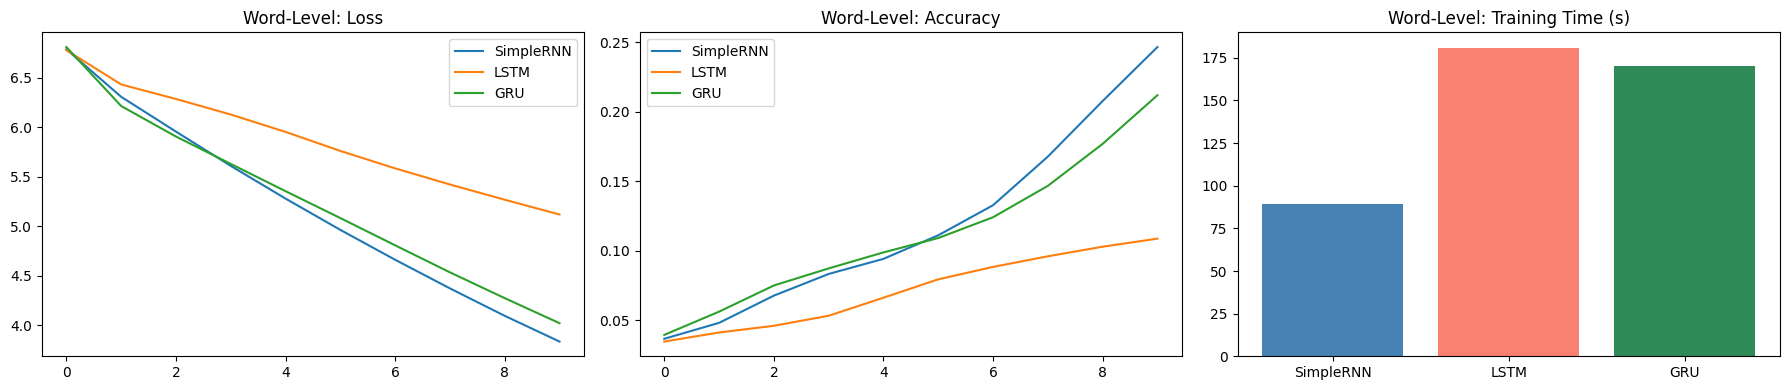


=== SimpleRNN ===
to be or not to be my spirit which well therefore shake the state if they not she go upon this messenger is mother i will thou refuge take him for they are young foreign notice

=== LSTM ===
to be or not to be such like sat frank against the death of lancaster of him and author as ope i sake my grant it aufidius for my shadow o one from those coriolanus then

=== GRU ===
to be or not to be hour for what duty have taught his fame and in us take up the devil how he bears can comes though now then it coffin'd along about i walls till

--- Training Word-LSTM-2Layer ---
Word-LSTM-2Layer | Time: 351.8s | Loss: 5.4919 | Acc: 0.0845

--- Training Word-GRU-2Layer ---
Word-GRU-2Layer | Time: 296.7s | Loss: 4.3848 | Acc: 0.1582

Single LSTM  — Loss: 5.1178, Acc: 0.1086, Time: 180.9s
2-Layer LSTM — Loss: 5.4919, Acc: 0.0845, Time: 351.8s
Single GRU   — Loss: 4.0208, Acc: 0.2118, Time: 170.4s
2-Layer GRU  — Loss: 4.3848, Acc: 0.1582, Time: 296.7s


In [3]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

word_text = re.sub(r"[^a-z\s']", ' ', text.lower())
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts([word_text])
vocab_size_w = min(5000, len(tokenizer.word_index) + 1)
encoded = np.array(tokenizer.texts_to_sequences([word_text])[0])
print(f'Word vocab size: {vocab_size_w}, Encoded length: {len(encoded)}')

SEQ_LEN_W = 20
BATCH_SIZE_W = 64
EPOCHS_W = 10

X_w = np.array([encoded[i:i+SEQ_LEN_W] for i in range(len(encoded)-SEQ_LEN_W)])
y_w = np.array([encoded[i+SEQ_LEN_W]   for i in range(len(encoded)-SEQ_LEN_W)])
word_dataset = tf.data.Dataset.from_tensor_slices((X_w, y_w))
word_dataset = word_dataset.shuffle(20000).batch(BATCH_SIZE_W, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

def build_word_model(rnn_type, units=128):
    model = keras.Sequential([
        layers.Embedding(vocab_size_w, 64, input_length=SEQ_LEN_W),
        rnn_type(units),
        layers.Dense(vocab_size_w, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def train_word_model(model, name):
    print(f'\n--- Training {name} ---')
    start = time.time()
    history = model.fit(word_dataset, epochs=EPOCHS_W, verbose=0)
    elapsed = time.time() - start
    print(f'{name} | Time: {elapsed:.1f}s | Loss: {history.history["loss"][-1]:.4f} | Acc: {history.history["accuracy"][-1]:.4f}')
    return elapsed, history.history['loss'][-1], history.history['accuracy'][-1], history

rnn_w  = build_word_model(layers.SimpleRNN)
lstm_w = build_word_model(layers.LSTM)
gru_w  = build_word_model(layers.GRU)

rnn_wt,  rnn_wl,  rnn_wa,  rnn_wh  = train_word_model(rnn_w,  'Word-SimpleRNN')
lstm_wt, lstm_wl, lstm_wa, lstm_wh = train_word_model(lstm_w, 'Word-LSTM')
gru_wt,  gru_wl,  gru_wa,  gru_wh  = train_word_model(gru_w,  'Word-GRU')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for hist, label in [(rnn_wh, 'SimpleRNN'), (lstm_wh, 'LSTM'), (gru_wh, 'GRU')]:
    axes[0].plot(hist.history['loss'], label=label)
    axes[1].plot(hist.history['accuracy'], label=label)
axes[0].set_title('Word-Level: Loss');     axes[0].legend()
axes[1].set_title('Word-Level: Accuracy'); axes[1].legend()
axes[2].bar(['SimpleRNN','LSTM','GRU'], [rnn_wt, lstm_wt, gru_wt], color=['steelblue','salmon','seagreen'])
axes[2].set_title('Word-Level: Training Time (s)')
plt.tight_layout(); plt.show()

idx2word = {v: k for k, v in tokenizer.word_index.items()}

def generate_words(model, seed_text, num_words=30, temperature=1.0):
    result = seed_text.split()
    for _ in range(num_words):
        enc = tokenizer.texts_to_sequences([' '.join(result[-SEQ_LEN_W:])])[0]
        enc = pad_sequences([enc], maxlen=SEQ_LEN_W, padding='pre')
        preds = model.predict(enc, verbose=0)[0]
        preds = np.log(preds + 1e-10) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        result.append(idx2word.get(np.random.choice(len(preds), p=preds), '<OOV>'))
    return ' '.join(result)

seed = 'to be or not to be'
for model, name in [(rnn_w, 'SimpleRNN'), (lstm_w, 'LSTM'), (gru_w, 'GRU')]:
    print(f'\n=== {name} ==='); print(generate_words(model, seed))

# Two-layer comparison
def build_word_model_2layer(rnn_type, units=128):
    model = keras.Sequential([
        layers.Embedding(vocab_size_w, 64, input_length=SEQ_LEN_W),
        rnn_type(units, return_sequences=True),
        rnn_type(units),
        layers.Dense(vocab_size_w, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_w2 = build_word_model_2layer(layers.LSTM)
gru_w2  = build_word_model_2layer(layers.GRU)
lstm_w2t, lstm_w2l, lstm_w2a, _ = train_word_model(lstm_w2, 'Word-LSTM-2Layer')
gru_w2t,  gru_w2l,  gru_w2a,  _ = train_word_model(gru_w2,  'Word-GRU-2Layer')

print(f'\nSingle LSTM  — Loss: {lstm_wl:.4f}, Acc: {lstm_wa:.4f}, Time: {lstm_wt:.1f}s')
print(f'2-Layer LSTM — Loss: {lstm_w2l:.4f}, Acc: {lstm_w2a:.4f}, Time: {lstm_w2t:.1f}s')
print(f'Single GRU   — Loss: {gru_wl:.4f}, Acc: {gru_wa:.4f}, Time: {gru_wt:.1f}s')
print(f'2-Layer GRU  — Loss: {gru_w2l:.4f}, Acc: {gru_w2a:.4f}, Time: {gru_w2t:.1f}s')

Question 2:
By tokenizing words into integers, the model can actually do math on them — the embedding layer turns each word ID into a dense vector, so related words end up close together in space. The generated text was noticeably more readable than char-level: all three models produced real English phrases like "the death of lancaster" and "what duty have taught his fame", even if they don't fully make sense. Interestingly, SimpleRNN had the best accuracy (24.65%) and lowest loss (3.83) while LSTM was the worst (10.86%): same story as Q1, simpler models converge faster with limited epochs. Adding a second layer actually hurt both LSTM and GRU (accuracy dropped, loss went up), which again comes down to needing more epochs to train the extra parameters. Word-level was also much slower overall since the output vocab (~4,900 words) makes the final Dense layer significantly heavier than char-level.

2026-04-06 05:14:18.104711: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-06 05:14:33.504684: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-06 05:14:41.994241: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
2026-04-06 05:14:47.728986: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



--- Training Stock-SimpleRNN ---
Stock-SimpleRNN | Time: 13.9s | Test MSE: 0.000808 | Test MAE: 0.0240

--- Training Stock-LSTM ---
Stock-LSTM | Time: 27.5s | Test MSE: 0.000465 | Test MAE: 0.0166

--- Training Stock-GRU ---
Stock-GRU | Time: 39.5s | Test MSE: 0.001289 | Test MAE: 0.0316


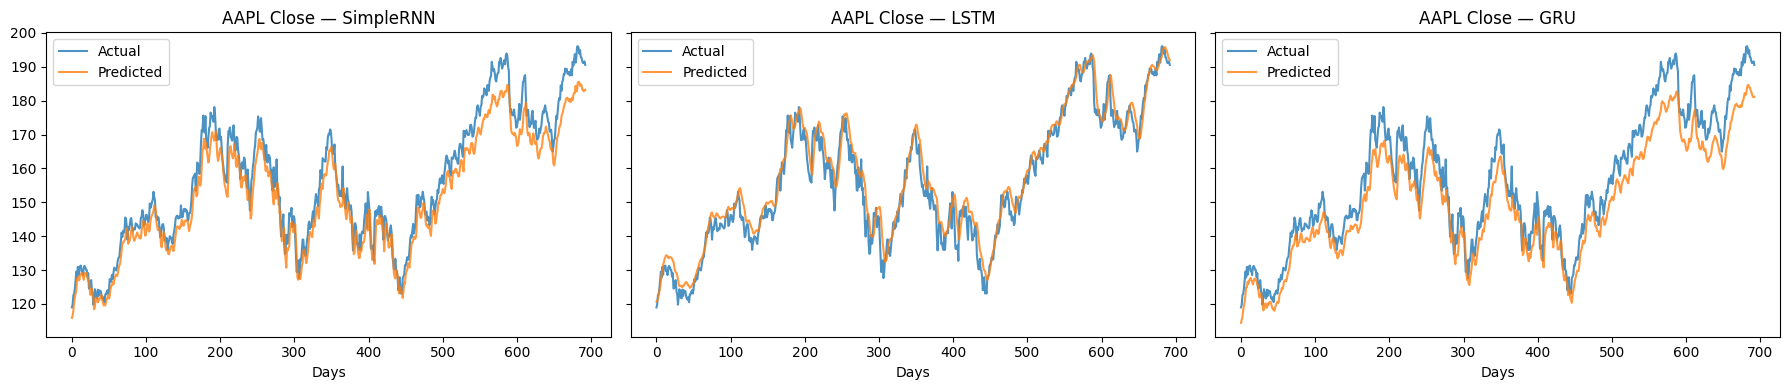

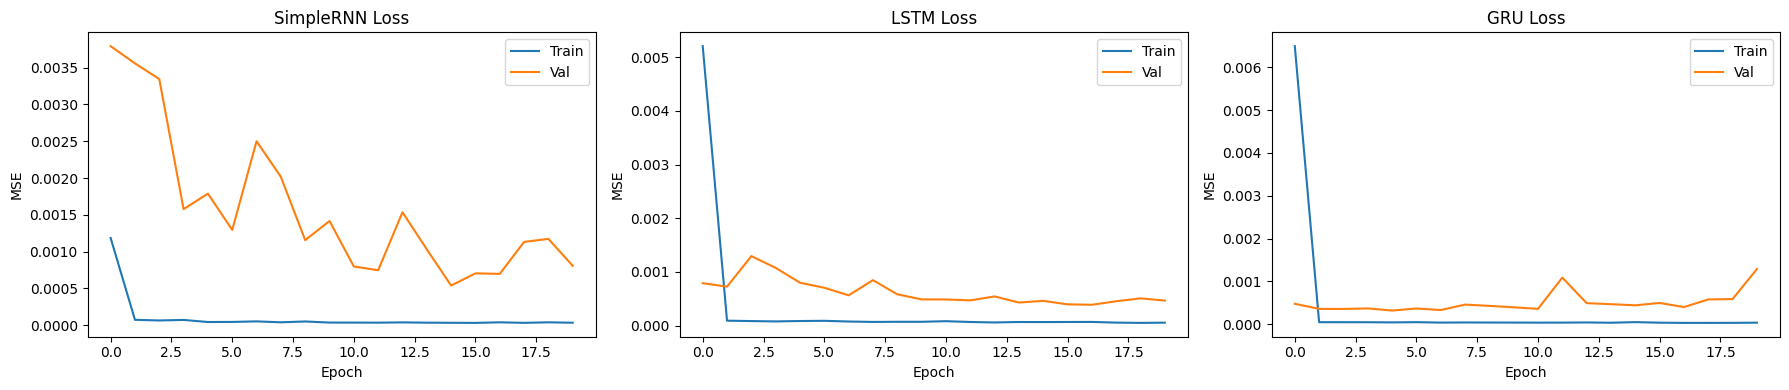


SimpleRNN  — Test MSE: 0.000808, MAE: 0.0240, Time: 13.9s
LSTM       — Test MSE: 0.000465, MAE: 0.0166, Time: 27.5s
GRU        — Test MSE: 0.001289, MAE: 0.0316, Time: 39.5s


In [4]:
import subprocess, sys
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Fix 1: upgrade yfinance + curl_cffi to support chrome136 impersonation
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade',
                       'yfinance', 'curl_cffi', '-q'])
import yfinance as yf

df = yf.download('AAPL', start='2010-01-01', end='2024-01-01', progress=False)[['Close']].dropna()
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df.values)

SEQ_LEN_S = 60
EPOCHS_S = 20
BATCH_SIZE_S = 32

X_s = np.array([scaled[i-SEQ_LEN_S:i, 0] for i in range(SEQ_LEN_S, len(scaled))])
y_s = np.array([scaled[i, 0]             for i in range(SEQ_LEN_S, len(scaled))])
X_s = X_s.reshape(X_s.shape[0], X_s.shape[1], 1)

split = int(len(X_s) * 0.8)
X_train, X_test = X_s[:split], X_s[split:]
y_train, y_test = y_s[:split], y_s[split:]

def build_stock_model(rnn_type, units=64):
    # Fix 2: use explicit Input layer instead of input_shape= to avoid Keras deprecation warning
    model = keras.Sequential([
        layers.Input(shape=(SEQ_LEN_S, 1)),
        rnn_type(units),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_stock_model(model, name):
    print(f'\n--- Training {name} ---')
    start = time.time()
    history = model.fit(X_train, y_train, epochs=EPOCHS_S, batch_size=BATCH_SIZE_S,
                        validation_data=(X_test, y_test), verbose=0)
    elapsed = time.time() - start
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f'{name} | Time: {elapsed:.1f}s | Test MSE: {test_loss:.6f} | Test MAE: {test_mae:.4f}')
    return elapsed, test_loss, test_mae, history

rnn_s  = build_stock_model(layers.SimpleRNN)
lstm_s = build_stock_model(layers.LSTM)
gru_s  = build_stock_model(layers.GRU)

rnn_st,  rnn_smse,  rnn_smae,  rnn_sh  = train_stock_model(rnn_s,  'Stock-SimpleRNN')
lstm_st, lstm_smse, lstm_smae, lstm_sh = train_stock_model(lstm_s, 'Stock-LSTM')
gru_st,  gru_smse,  gru_smae,  gru_sh  = train_stock_model(gru_s,  'Stock-GRU')

actual = scaler.inverse_transform(y_test.reshape(-1, 1))
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, model, name in [(axes[0], rnn_s, 'SimpleRNN'), (axes[1], lstm_s, 'LSTM'), (axes[2], gru_s, 'GRU')]:
    preds = scaler.inverse_transform(model.predict(X_test, verbose=0))
    ax.plot(actual, label='Actual', alpha=0.8)
    ax.plot(preds,  label='Predicted', alpha=0.8)
    ax.set_title(f'AAPL Close — {name}'); ax.set_xlabel('Days'); ax.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, name in [(axes[0], rnn_sh, 'SimpleRNN'), (axes[1], lstm_sh, 'LSTM'), (axes[2], gru_sh, 'GRU')]:
    ax.plot(hist.history['loss'], label='Train'); ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(f'{name} Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.show()

print(f'\nSimpleRNN  — Test MSE: {rnn_smse:.6f}, MAE: {rnn_smae:.4f}, Time: {rnn_st:.1f}s')
print(f'LSTM       — Test MSE: {lstm_smse:.6f}, MAE: {lstm_smae:.4f}, Time: {lstm_st:.1f}s')
print(f'GRU        — Test MSE: {gru_smse:.6f}, MAE: {gru_smae:.4f}, Time: {gru_st:.1f}s')

Question 3:
Stock data is much simpler to set up than text: just normalize the closing prices to [0,1] and feed in 60-day windows. All three models visually tracked the general trend but lagged behind the actual price, basically echoing yesterday's price rather than predicting tomorrow's. LSTM performed best with the lowest MSE (0.000465) and MAE (0.0166), whilst GRU came in last (MSE 0.000808) despite usually being competitive. None of them can actually make you rich though...: stock prices already reflect all public information (Efficient Market Hypothesis), the models overfit to bull-market trends, and even if predictions were decent, transaction costs would eat any profit.